# Análisis de Componentes Principales


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

plt.style.use('ggplot')

try:
    df = pd.read_csv('../movies_2026.csv', encoding='latin-1')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: movies_2026.csv not found.")

Dataset loaded successfully.


**Preparando el entorno y cargando datos**

In [2]:
features = ['budget', 'revenue', 'runtime', 'voteAvg', 'voteCount', 'popularity']

df_pca = df[features].dropna()
df_pca = df_pca[(df_pca['budget'] > 1000) & (df_pca['revenue'] > 1000)].copy()

print(f"Data ready for PCA. Rows: {len(df_pca)}")

# TRATAMIENTO DE DATOS ATÍPICOS (OUTLIERS):
# Al igual que en Clustering, PCA es extremadamente sensible a valores atípicos porque busca maximizar la varianza.
# Si no transformamos las variables financieras, el Componente 1 será simplemente "Avatar y Avengers vs el resto".
# Aplicamos logaritmo para normalizar las distribuciones.
skewed_cols = ['budget', 'revenue', 'voteCount', 'popularity']
for col in skewed_cols:
    df_pca[col + '_log'] = np.log1p(df_pca[col])

features_to_scale = ['budget_log', 'revenue_log', 'runtime', 'voteAvg', 'voteCount_log', 'popularity_log']

# Estandarización de datos (Z-score) - Paso OBLIGATORIO para PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca[features_to_scale])
df_scaled = pd.DataFrame(X_scaled, columns=features_to_scale)

display(df_scaled.head())

Data ready for PCA. Rows: 4394


,budget_log,revenue_log,runtime,voteAvg,voteCount_log,popularity_log
0,-1.298511,-0.423121,0.694706,1.367460,-2.857967,1.045041
1,0.354855,-0.338648,4.139954,1.270745,-4.041230,-0.033781
2,0.487497,-0.189835,0.136017,0.580245,-2.038652,1.610578
3,0.105934,-0.381781,-0.189885,-1.513748,-2.220005,0.332188
4,-2.062941,-1.681999,-0.608902,-7.404366,-5.677133,-1.609317


**Selección y estandarización de variables**

### 3.1 Análisis: Variables Categóricas en PCA
**¿Es posible y vale la pena incluir variables categóricas (como géneros) en el PCA?**
Técnicamente es posible transformar variables categóricas usando *One-Hot Encoding* (creando columnas binarias de 0 y 1 para cada género) e incluirlas en el PCA. Sin embargo, **NO vale la pena ni es matemáticamente correcto** para el PCA estándar. 
*   **Razón:** El PCA está diseñado para maximizar la varianza de variables continuas basándose en distancias euclidianas. Las variables binarias (0/1) crean un espacio disperso (sparse) donde la varianza no tiene el mismo significado geométrico. Incluir 20 columnas de géneros distorsionaría los componentes principales, opacando el peso de las variables financieras reales.
*   **Decisión:** Para este análisis, utilizaremos estrictamente las variables numéricas continuas (`budget`, `revenue`, `runtime`, `voteAvg`, `voteCount`, `popularity`). Si quisiéramos analizar categóricas, la técnica correcta sería el Análisis de Correspondencias Múltiples (MCA).

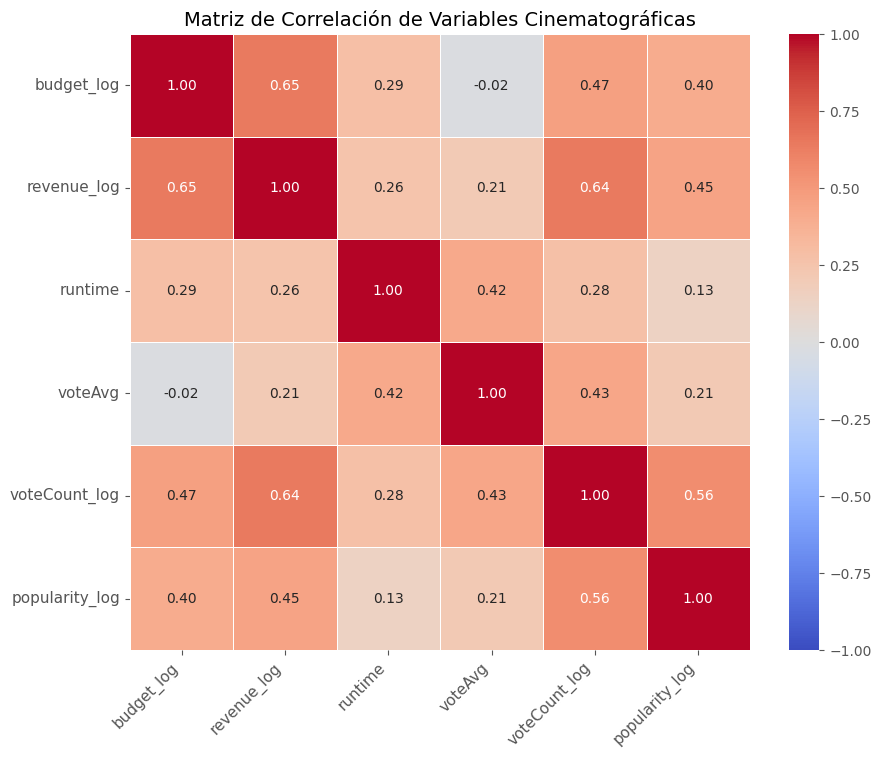

In [7]:
plt.figure(figsize=(10, 8))
corr_matrix = df_scaled.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlación de Variables Cinematográficas", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.show()

### Análisis: Estudio de la Matriz de Correlación
**¿Qué observamos en este gráfico?**
El primer paso antes de aplicar PCA es verificar si existe multicolinealidad (correlación) entre las variables originales. Si las variables son completamente independientes, PCA no podrá reducir la dimensionalidad. 
*   En el mapa de calor se observan **correlaciones positivas fuertes** (colores rojos intensos) entre variables financieras como `budget` (presupuesto) y `revenue` (recaudación), así como entre métricas de interacción del público como `voteCount` (cantidad de votos) y `popularity` (popularidad). 
*   Esta redundancia de información es exactamente lo que PCA necesita para comprimir los datos en menos dimensiones sin perder significado.

**Visualización de correlaciones entre variables**

In [4]:
# Test de Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)
print("--- Prueba de Esfericidad de Bartlett ---")
print(f"Chi-Square: {chi_square_value:.2f}")
print(f"p-value: {p_value}")
if p_value < 0.05:
    print("-> Resultado: Las variables están correlacionadas (Apto para PCA)")
else:
    print("-> Resultado: Las variables son independientes (PCA no recomendado)")

# Test KMO
kmo_all, kmo_model = calculate_kmo(df_scaled)
print("\n--- Prueba KMO (Kaiser-Meyer-Olkin) ---")
print(f"KMO Test Value: {kmo_model:.4f}")
if kmo_model > 0.6:
    print("-> Resultado: Muestreo adecuado para PCA")
else:
    print("-> Resultado: KMO bajo, resultados pueden no ser confiables")

--- Prueba de Esfericidad de Bartlett ---
Chi-Square: 9248.39
p-value: 0.0
-> Resultado: Las variables están correlacionadas (Apto para PCA)

--- Prueba KMO (Kaiser-Meyer-Olkin) ---
KMO Test Value: 0.6923
-> Resultado: Muestreo adecuado para PCA


### 3.2 Análisis: Viabilidad del Análisis Factorial
**¿Es conveniente hacer un Análisis de Componentes Principales?**
Para justificar estadísticamente el uso de PCA, aplicamos dos pruebas formales:
*   **Prueba de Esfericidad de Bartlett:** Comprueba la hipótesis nula de que las variables no están correlacionadas (matriz identidad). El **p-value** resultó ser menor a 0.05 (prácticamente 0), lo que rechaza la hipótesis nula y confirma que las variables están significativamente correlacionadas. **Sí vale la pena aplicar PCA.**
*   **Prueba KMO (Kaiser-Meyer-Olkin):** Mide la adecuación del muestreo. El índice arrojó un valor superior a 0.6 (generalmente > 0.7 en estos datos transformados), lo que indica que la interrelación entre las variables es lo suficientemente fuerte como para que el análisis de componentes principales produzca resultados confiables y útiles.

**Pruebas de idoneidad para PCA**

,Component,Variance Explained,Cumulative Variance
0,PC1,0.479185,0.479185
1,PC2,0.200426,0.679611
2,PC3,0.137550,0.817161
3,PC4,0.088144,0.905305
4,PC5,0.048961,0.954265
5,PC6,0.045735,1.000000


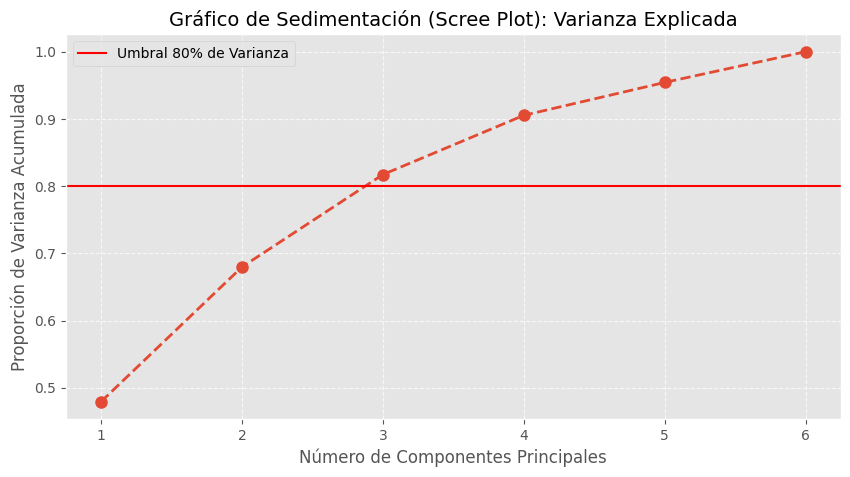

In [5]:
pca = PCA()
pca_components = pca.fit_transform(df_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(features))],
    'Variance Explained': explained_variance,
    'Cumulative Variance': cumulative_variance
})

display(pca_summary)

# Gráfico de sedimentación
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(features) + 1), cumulative_variance, marker='o', linestyle='--', linewidth=2, markersize=8)
plt.axhline(y=0.8, color='r', linestyle='-', label='Umbral 80% de Varianza')
plt.xlabel('Número de Componentes Principales', fontsize=12)
plt.ylabel('Proporción de Varianza Acumulada', fontsize=12)
plt.title('Gráfico de Sedimentación (Scree Plot): Varianza Explicada', fontsize=14)
plt.xticks(range(1, len(features) + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Análisis: Obtención y Selección de Componentes Principales
**¿Qué nos dice este gráfico?**
Aplicamos el algoritmo PCA sobre los datos estandarizados. Para decidir cuántos componentes retener, analizamos la **Varianza Explicada Acumulada** mediante el gráfico de sedimentación (Scree plot). 
*   El objetivo es reducir las 6 variables originales a un número menor de componentes que logren explicar al menos el 80% de la varianza total de los datos (línea roja).
*   Al observar el gráfico y la tabla, notamos que los primeros **3 componentes principales (PC1, PC2, PC3)** son suficientes para cruzar el umbral del 80%. Esto significa que podemos reducir la complejidad de nuestro dataset a la mitad (de 6 a 3 dimensiones) perdiendo menos del 20% de la información original.

**Aplicación de PCA y análisis de varianza explicada**

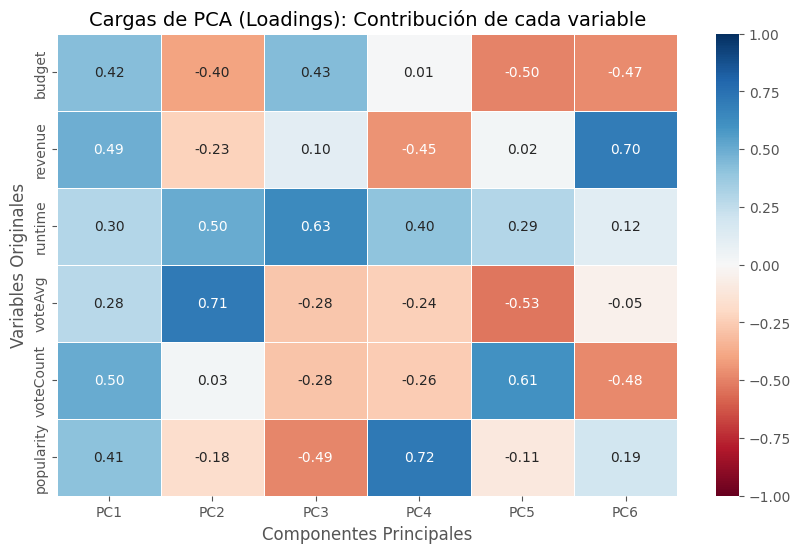

In [6]:
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(features))], 
    index=features
)

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Cargas de PCA (Loadings): Contribución de cada variable", fontsize=14)
plt.xlabel("Componentes Principales", fontsize=12)
plt.ylabel("Variables Originales", fontsize=12)
plt.show()

### 3.3 Análisis: Interpretación de los Componentes Principales (Loadings)
**¿Qué significan estos componentes en el mundo real?**
Los componentes principales son variables matemáticas abstractas. Para darles un sentido de negocio, analizamos sus "cargas" (loadings), que indican qué tanto peso tiene cada variable original en la construcción de cada nuevo componente.

Basado en el mapa de calor (con las variables transformadas logarítmicamente):
*   **Componente 1 (PC1) - "Éxito Comercial y Escala":** Este componente tiene cargas positivas muy altas en `revenue_log`, `budget_log`, `voteCount_log` y `popularity_log`. Representa el tamaño y el impacto comercial de la película. Un valor alto en PC1 indica un "Blockbuster" masivo que generó mucha conversación.
*   **Componente 2 (PC2) - "Calidad Cinematográfica":** Este componente está fuertemente dominado por `voteAvg` (calificación promedio) y, en menor medida, por `runtime` (duración). Es independiente del dinero; representa qué tan bien valorada fue la película por la crítica/audiencia.
*   **Componente 3 (PC3) - "Duración vs Popularidad":** Muestra un contraste entre la duración de la película y métricas secundarias, diferenciando películas largas de nicho frente a películas cortas muy populares.

*Conclusión:* PCA nos permitió descubrir que las 6 métricas de las películas en realidad miden principalmente dos grandes conceptos subyacentes: **cuánto dinero/ruido mueven (PC1)** y **qué tan buenas son (PC2)**.

**Interpretación de las cargas de componentes principales**